# 💳 AI-Powered Fraud Detection Using CTGAN

### Project Type
Classification + Generative AI

### Contribution
Chanda Sushmasri


## 📌 Project Summary

This project focuses on detecting fraudulent financial transactions using Machine Learning and CTGAN-generated synthetic fraud data.

The dataset is highly imbalanced, with fraudulent transactions representing only a very small percentage of total transactions. To address this issue, CTGAN (Conditional Tabular GAN) was used to generate synthetic fraud samples and improve fraud detection performance.

The workflow includes:

- Data preprocessing
- Exploratory Data Analysis (EDA)
- Class imbalance analysis
- Synthetic fraud generation using CTGAN
- Model training and evaluation
- Comparison between baseline and augmented models
- Interactive Streamlit dashboard deployment

The final system allows users to upload transaction datasets and automatically detect potentially fraudulent transactions using an AI-powered dashboard.

## 🎯 Problem Statement
To improve fraud detection performance on highly imbalanced financial transaction datasets using CTGAN-generated synthetic fraud transactions.

## GitHub Link - https://github.com/sushmasriC/AI-Fraud-Detection-Using-*CTGAN*

# 1️⃣ Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

print("Libraries Imported Successfully")

Libraries Imported Successfully


# 2️⃣ Dataset Loading

In [3]:
# Load dataset
df = pd.read_csv('/content/creditcard.csv')

print("Dataset Loaded Successfully")

# Shape of dataset
print("Dataset Shape:", df.shape)

Dataset Loaded Successfully
Dataset Shape: (284807, 31)


## Dataset Overview

The dataset contains anonymized credit card transaction features generated using PCA transformation.

### Features
- V1–V28 → PCA-transformed features
- Time → transaction timestamp
- Amount → transaction amount
- Class → target variable
    - 0 = Normal
    - 1 = Fraud

In [4]:
# Check missing values
missing_values = df.isnull().sum()

print(missing_values)

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [5]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

# 3️⃣ Class Imbalance Analysis

In [6]:
# Class distribution
class_counts = df['Class'].value_counts()

print(class_counts)

Class
0    284315
1       492
Name: count, dtype: int64


In [7]:
# Fraud percentage
fraud_percentage = (
    class_counts[1] / len(df)
) * 100

print(f"Fraud Percentage: {fraud_percentage:.4f}%")

Fraud Percentage: 0.1727%


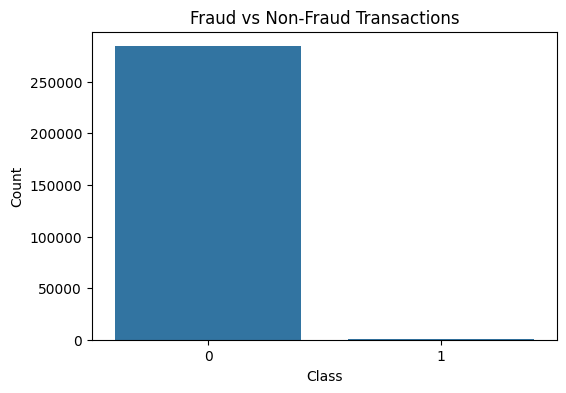

In [8]:
# Visualize class imbalance
plt.figure(figsize=(6,4))

sns.countplot(
    x='Class',
    data=df
)

plt.title("Fraud vs Non-Fraud Transactions")

plt.xlabel("Class")

plt.ylabel("Count")

plt.show()

### Why this chart?

To understand the imbalance between fraudulent and non-fraudulent transactions.

### Insight

The dataset is extremely imbalanced, with fraud transactions representing a very small percentage of total transactions.

### Analysis

Such imbalance can cause machine learning models to become biased toward predicting normal transactions. Therefore, synthetic fraud generation is necessary.

# 4️⃣ Exploratory Data Analysis (EDA)

## Transaction Amount Distribution

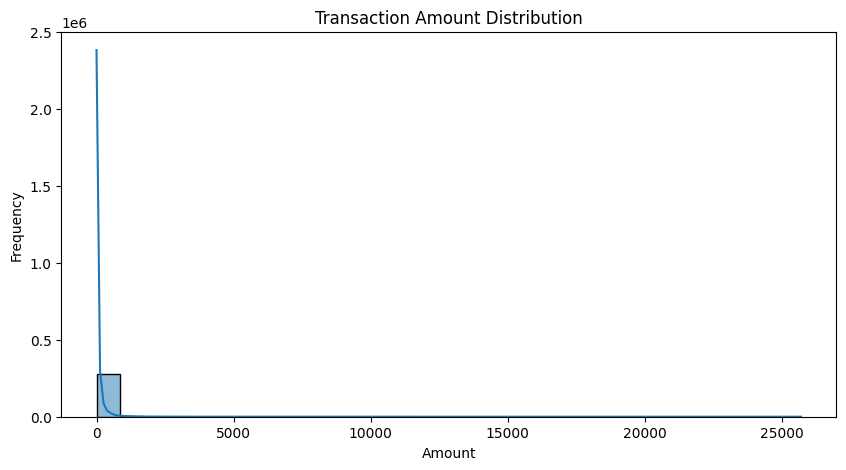

In [9]:
# Transaction Amount Distribution
plt.figure(figsize=(10,5))

sns.histplot(
    df['Amount'],
    bins=30,
    kde=True
)

plt.title("Transaction Amount Distribution")

plt.xlabel("Amount")

plt.ylabel("Frequency")

plt.show()

### Why this chart?

To analyze how transaction amounts are distributed.

### Insight

Most transactions are concentrated at lower amounts, with a few high-value outliers.

### Analysis

The distribution is highly skewed, indicating the presence of unusual transaction patterns.

## Transaction Time Distribution

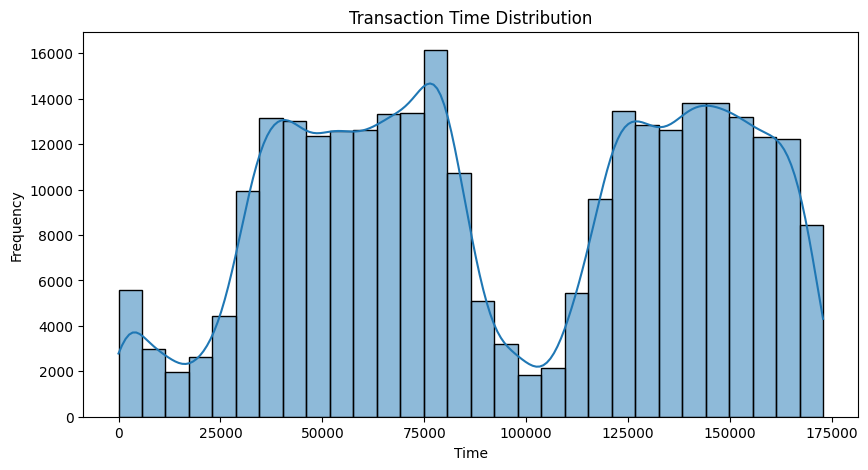

In [10]:
# Time Distribution
plt.figure(figsize=(10,5))

sns.histplot(
    df['Time'],
    bins=30,
    kde=True
)

plt.title("Transaction Time Distribution")

plt.xlabel("Time")

plt.ylabel("Frequency")

plt.show()

### Why this chart?

To analyze how transactions are distributed over time.

### What does it show?

The histogram displays the frequency of transactions across different time intervals.

### Insight

Transactions occur continuously throughout the observed time period, with some fluctuations in transaction density.

### Analysis

Understanding transaction timing patterns helps identify unusual activity and potential fraud spikes occurring during specific time intervals.

# 5️⃣ Feature Correlation Analysis

## Correlation Heatmap

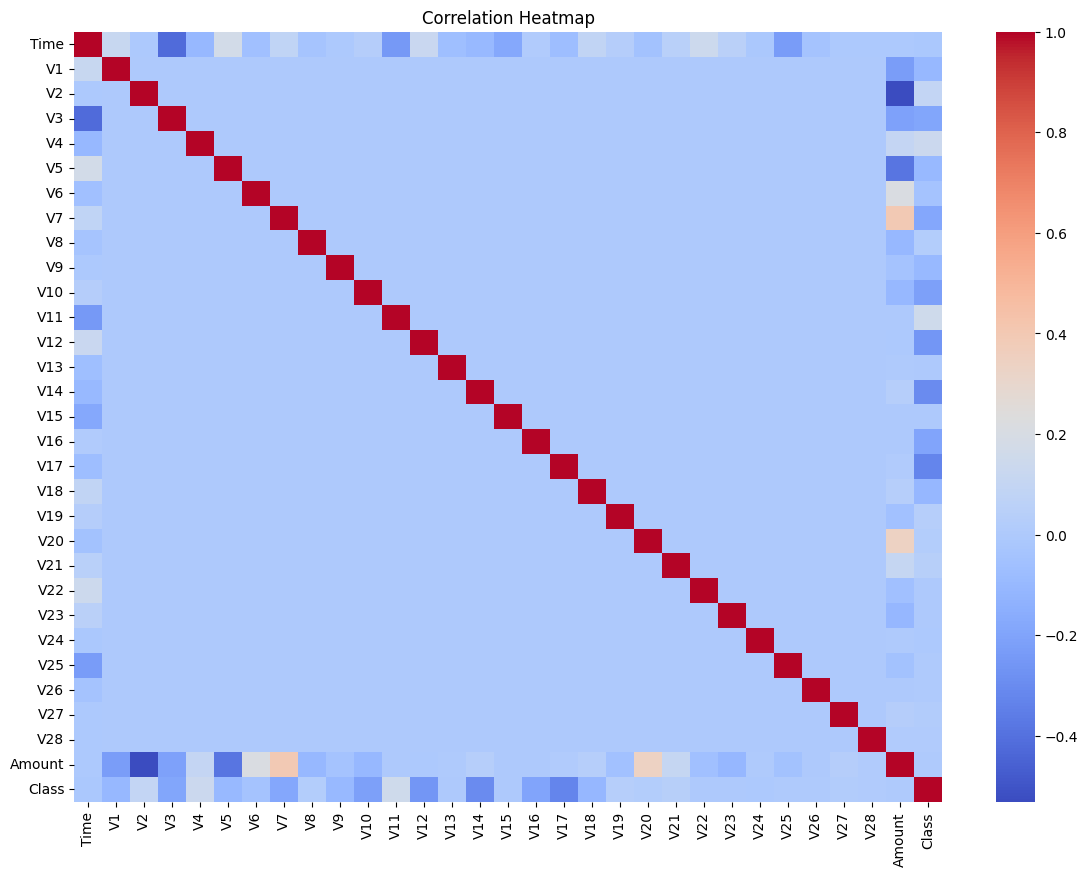

In [11]:
# Correlation Heatmap
plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(),
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

### Why this chart?

To understand relationships between transaction features and identify highly correlated variables.

### What does it show?

The heatmap visualizes correlation values between all numerical features in the dataset.

### Insight

Most PCA-transformed features show low correlation with each other, indicating that the dataset has reduced redundancy between variables.

### Analysis

Low feature correlation is beneficial for machine learning models because it reduces multicollinearity and helps models learn more effectively from independent patterns.

# 6️⃣ Preparing Data for CTGAN

## Separating Fraud and Normal Transactions

In [12]:
# Separate fraud and normal transactions
fraud_df = df[df['Class'] == 1]

normal_df = df[df['Class'] == 0]

print("Fraud Shape:", fraud_df.shape)

print("Normal Shape:", normal_df.shape)

Fraud Shape: (492, 31)
Normal Shape: (284315, 31)


### Why is this step important?

The dataset is highly imbalanced, with very few fraud transactions compared to normal transactions.

### Objective

To train CTGAN specifically on fraudulent transaction patterns so that synthetic fraud samples can be generated.

### Insight

By isolating fraud transactions, CTGAN can learn the characteristics and distribution of fraudulent behavior more effectively.

### Analysis

Synthetic fraud generation helps improve class balance and enhances the model’s ability to detect rare fraud cases.

## Fraud vs Normal Transaction Amount Distribution

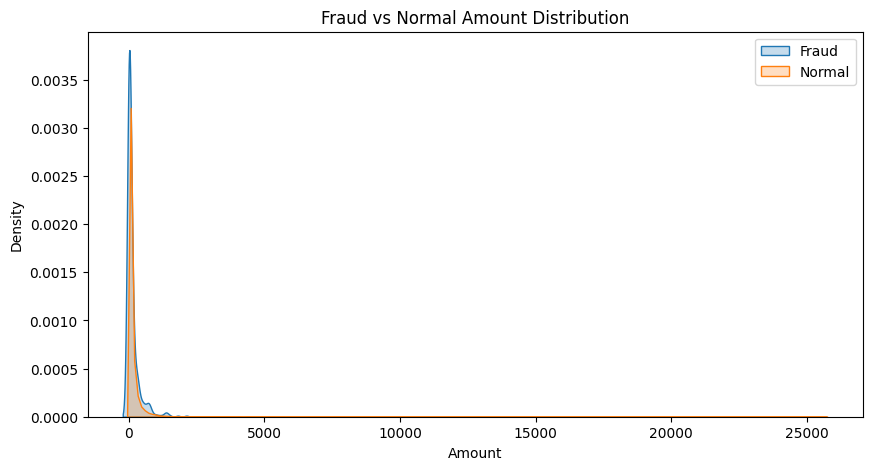

In [13]:
# Fraud vs Normal Amount Distribution
plt.figure(figsize=(10,5))

sns.kdeplot(
    fraud_df['Amount'],
    label='Fraud',
    fill=True
)

sns.kdeplot(
    normal_df['Amount'],
    label='Normal',
    fill=True
)

plt.title("Fraud vs Normal Amount Distribution")

plt.xlabel("Amount")

plt.ylabel("Density")

plt.legend()

plt.show()

### Why this chart?

To compare transaction amount patterns between fraudulent and normal transactions.

### What does it show?

The graph compares the density distribution of transaction amounts for fraud and non-fraud transactions.

### Insight

Fraudulent transactions occur across various transaction ranges and show different density behavior compared to normal transactions.

### Analysis

This comparison helps identify behavioral differences between fraud and non-fraud transactions, which can improve fraud detection model learning.

# 7️⃣ Feature Scaling and Data Preparation

In [14]:
# Feature Scaling
scaler = StandardScaler()

df['Amount'] = scaler.fit_transform(
    df[['Amount']]
)

df['Time'] = scaler.fit_transform(
    df[['Time']]
)

print("Feature Scaling Completed")

Feature Scaling Completed


### Why is feature scaling required?

Feature scaling standardizes numerical values and improves model consistency during training.

### Features Scaled

- Time
- Amount

### Analysis

Scaling prevents features with larger magnitudes from dominating the learning process and improves numerical stability for machine learning models.

## Feature and Target Separation

In [15]:
# Features and target
X = df.drop('Class', axis=1)

y = df['Class']

print("Feature Shape:", X.shape)

print("Target Shape:", y.shape)

Feature Shape: (284807, 30)
Target Shape: (284807,)


### Objective

To separate input features and target labels for machine learning model training.

### Features

- Time
- V1–V28
- Amount

### Target

- Class
    - 0 = Normal
    - 1 = Fraud

## Train-Test Data Splitting

In [16]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Training Shape:", X_train.shape)

print("Testing Shape:", X_test.shape)

Training Shape: (227845, 30)
Testing Shape: (56962, 30)


### Why split the dataset?

To evaluate model performance on unseen data and reduce the risk of overfitting.

### Split Ratio

- Training Data → 80%
- Testing Data → 20%

### Analysis

The training dataset is used for learning patterns, while the testing dataset is used to evaluate real-world fraud detection performance.

## Training Dataset Class Distribution

In [17]:
# Training class distribution
print(y_train.value_counts())

Class
0    227451
1       394
Name: count, dtype: int64


### Why check training distribution?

To verify whether the training dataset maintains the original class imbalance.

### Insight

The training dataset still contains significantly fewer fraud transactions compared to normal transactions.

### Analysis

This confirms the need for synthetic fraud generation using CTGAN to improve fraud representation during model training.

## Testing Dataset Class Distribution

In [18]:
# Testing class distribution
print(y_test.value_counts())

Class
0    56864
1       98
Name: count, dtype: int64


### Why check testing distribution?

To ensure that the testing dataset reflects realistic fraud occurrence patterns.

### Analysis

Maintaining class imbalance in the testing dataset allows accurate evaluation of real-world fraud detection performance.

## Rebuilding Training DataFrame

In [19]:
# Rebuild training dataframe
train_df = X_train.copy()

train_df['Class'] = y_train

print("Training DataFrame Shape:", train_df.shape)

Training DataFrame Shape: (227845, 31)


### Objective

To combine training features and target labels into a single dataframe for CTGAN training preparation.

### Analysis

CTGAN requires a complete dataframe containing both features and labels for synthetic data generation.

## Extracting Fraud-Only Training Data

In [20]:
# Fraud-only training data
train_fraud_df = train_df[
    train_df['Class'] == 1
]

print("Fraud Training Shape:", train_fraud_df.shape)

Fraud Training Shape: (394, 31)


### Why isolate fraud transactions?

CTGAN is trained specifically on fraudulent transaction patterns.

### Analysis

By focusing only on fraud samples, CTGAN can learn the characteristics of fraudulent behavior more effectively and generate realistic synthetic fraud transactions.

In [21]:
!pip install sdv -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.7/204.7 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 50.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.3/202.3 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 70.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 6.9 MB/s eta 0:00:00


In [22]:
# Import CTGAN
from sdv.single_table import CTGANSynthesizer
from sdv.metadata import SingleTableMetadata

print("CTGAN Imported Successfully")

CTGAN Imported Successfully


# 8️⃣ CTGAN Synthetic Data Generation

## Metadata Detection

In [23]:
# Create metadata
metadata = SingleTableMetadata()

metadata.detect_from_dataframe(
    data=train_fraud_df
)

print("Metadata Created Successfully")

Metadata Created Successfully


### Why metadata detection?

CTGAN requires metadata to understand dataset structure and feature types before synthetic data generation.

### Analysis

Automatic metadata detection improves synthetic data consistency and training quality.

## CTGAN Model Initialization

In [24]:
# Initialize CTGAN
ctgan = CTGANSynthesizer(
    metadata,
    epochs=100
)

print("CTGAN Initialized Successfully")

CTGAN Initialized Successfully


### CTGAN Configuration

The CTGAN model is initialized with 100 training epochs to learn fraud transaction distributions effectively.

### Analysis

More training epochs help CTGAN generate more realistic synthetic fraud samples.

## Training CTGAN Model

In [25]:
# Train CTGAN
ctgan.fit(train_fraud_df)

print("CTGAN Training Completed")

CTGAN Training Completed


### CTGAN Training Summary

The CTGAN model successfully learned fraudulent transaction patterns from the training dataset.

### Analysis

This trained model can now generate synthetic fraud samples for dataset augmentation.

## Generating Synthetic Fraud Transactions

In [26]:
# Generate synthetic fraud samples
synthetic_fraud = ctgan.sample(
    num_rows=2000
)

print("Synthetic Fraud Shape:", synthetic_fraud.shape)

Synthetic Fraud Shape: (2000, 31)


### Synthetic Data Generation

CTGAN generated 2000 synthetic fraud transactions based on learned fraud patterns.

### Analysis

These synthetic samples will be combined with real data to improve fraud detection performance.

In [27]:
# Preview synthetic fraud data
synthetic_fraud.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.439960,-2.076757,-2.257620,-7.414044,2.473160,11.095089,-2.098637,-1.816979,0.872204,-6.929961,...,1.451571,-0.966065,1.022386,-1.076162,0.461995,-0.339769,-0.683580,1.680309,-0.162078,1
1,-0.482530,-5.655086,-8.402154,-11.324491,-1.313275,4.160215,-2.408400,2.727477,1.087270,-3.730945,...,0.894443,1.376651,0.552941,-1.051438,0.437628,0.819070,-4.414341,-0.385413,-0.353229,1
2,0.303606,-8.928376,-1.580915,-21.863306,-1.313275,5.381992,-2.377903,0.257449,1.733736,-3.642032,...,2.048892,0.382444,0.120263,-1.588290,0.973130,1.504857,-4.236461,-1.869290,-0.308558,1
3,-0.731254,-7.058497,-2.453546,0.400855,3.644346,-0.043988,-0.073607,3.856452,-1.371030,-5.442425,...,0.281712,-1.916621,-0.507167,-1.154474,2.208209,0.766936,-0.594023,-0.452421,-0.353229,1
4,-0.662816,0.826253,-2.797187,-11.648584,3.396846,6.441361,0.442619,-10.281024,-2.749556,-4.609937,...,3.385173,-0.915405,-0.384984,0.421861,0.719565,0.771614,-0.831572,1.779364,-0.353229,1


In [28]:
# Ensure all synthetic samples are fraud
synthetic_fraud['Class'] = 1

print(
    synthetic_fraud['Class'].value_counts()
)

Class
1    2000
Name: count, dtype: int64


# 9️⃣ Real vs Synthetic Fraud Comparison

## Transaction Amount Distribution Comparison

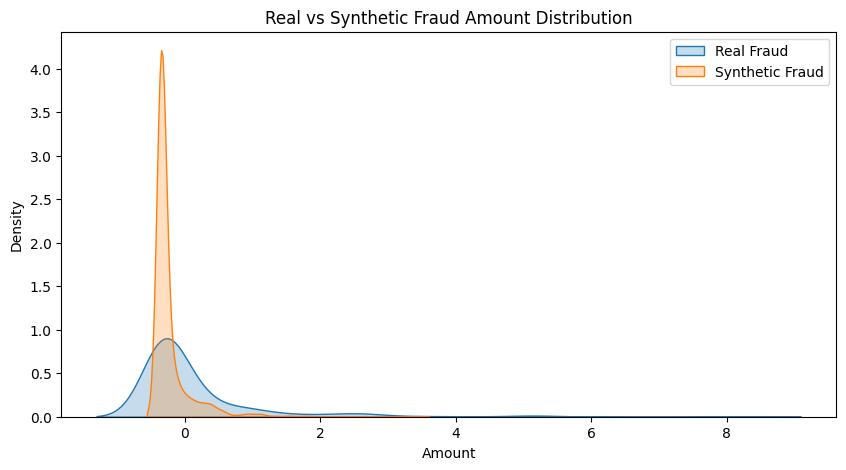

In [29]:
# Real vs Synthetic Fraud Amount Distribution
plt.figure(figsize=(10,5))

sns.kdeplot(
    train_fraud_df['Amount'],
    label='Real Fraud',
    fill=True
)

sns.kdeplot(
    synthetic_fraud['Amount'],
    label='Synthetic Fraud',
    fill=True
)

plt.title(
    "Real vs Synthetic Fraud Amount Distribution"
)

plt.xlabel("Amount")

plt.ylabel("Density")

plt.legend()

plt.show()

### Insight

The synthetic fraud distribution closely resembles the real fraud transaction distribution.

### Analysis

This indicates that CTGAN successfully captured important fraud transaction characteristics.

## Transaction Time Distribution Comparison

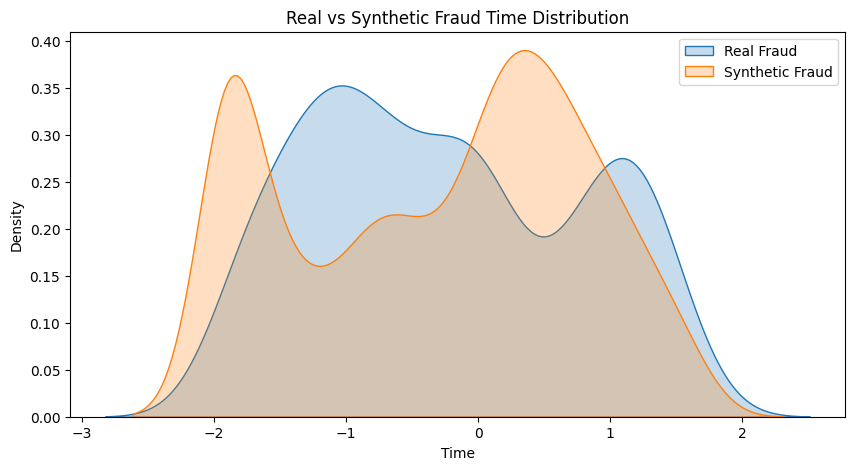

In [30]:
# Real vs Synthetic Time Distribution
plt.figure(figsize=(10,5))

sns.kdeplot(
    train_fraud_df['Time'],
    label='Real Fraud',
    fill=True
)

sns.kdeplot(
    synthetic_fraud['Time'],
    label='Synthetic Fraud',
    fill=True
)

plt.title(
    "Real vs Synthetic Fraud Time Distribution"
)

plt.xlabel("Time")

plt.ylabel("Density")

plt.legend()

plt.show()

### Insight

Synthetic fraud transactions follow temporal patterns similar to real fraud transactions.

### Analysis

This suggests that CTGAN learned meaningful timing behavior from fraud data.

## PCA Visualization: Real vs Synthetic Fraud Data

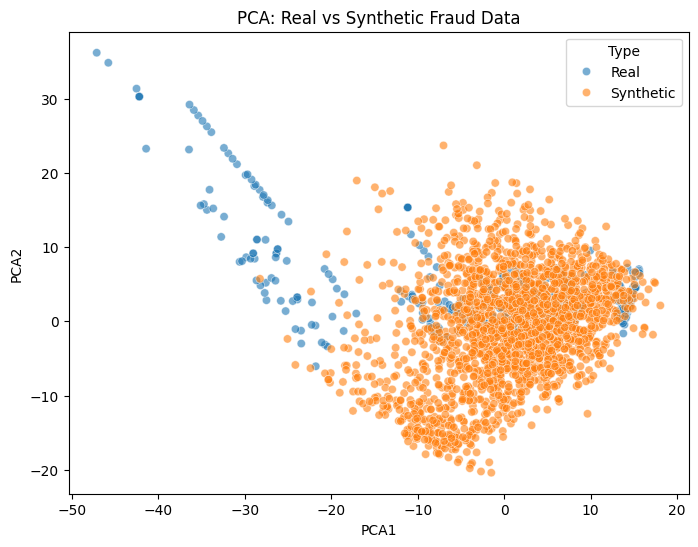

In [31]:
# PCA Visualization
from sklearn.decomposition import PCA

# Combine datasets
comparison_df = pd.concat([
    train_fraud_df.assign(Type='Real'),
    synthetic_fraud.assign(Type='Synthetic')
])

# Features only
X_pca = comparison_df.drop(
    ['Class', 'Type'],
    axis=1
)

# PCA
pca = PCA(n_components=2)

pca_result = pca.fit_transform(X_pca)

# Create dataframe
pca_df = pd.DataFrame()

pca_df['PCA1'] = pca_result[:,0]

pca_df['PCA2'] = pca_result[:,1]

pca_df['Type'] = comparison_df['Type'].values

# Plot
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x='PCA1',
    y='PCA2',
    hue='Type',
    alpha=0.6
)

plt.title(
    "PCA: Real vs Synthetic Fraud Data"
)

plt.show()

### Why PCA Visualization?

PCA reduces high-dimensional data into two dimensions for visualization.

### Insight

Real and synthetic fraud samples overlap significantly.

### Analysis

This overlap indicates that CTGAN generated realistic synthetic fraud transactions similar to the original fraud distribution.

In [32]:
# Save synthetic fraud dataset
synthetic_fraud.to_csv(
    "synthetic_fraud.csv",
    index=False
)

print("Synthetic Fraud Dataset Saved")

Synthetic Fraud Dataset Saved


In [33]:
# Save CTGAN model
ctgan.save(
    "ctgan_model.pkl"
)

print("CTGAN Model Saved")

CTGAN Model Saved


In [34]:
# Import Random Forest
from sklearn.ensemble import RandomForestClassifier

# Create baseline model
baseline_model = RandomForestClassifier(
    random_state=42,
    n_estimators=100,
    class_weight='balanced'
)

# Train baseline model
baseline_model.fit(
    X_train,
    y_train
)

print("Baseline Model Training Completed")

Baseline Model Training Completed


# 🔟 Baseline Fraud Detection Model

### Model Used

Random Forest Classifier

### Why Random Forest?

Random Forest is a robust ensemble machine learning algorithm that performs well on tabular datasets and handles complex fraud patterns effectively.

### Analysis

The baseline model is trained using the original imbalanced dataset to evaluate fraud detection performance before synthetic augmentation.

In [35]:
# Baseline predictions
baseline_pred = baseline_model.predict(X_test)

print("Predictions Generated")

Predictions Generated


In [36]:
# Import metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_auc_score
)

# Accuracy
baseline_accuracy = accuracy_score(
    y_test,
    baseline_pred
)

print(
    f"Baseline Accuracy: {baseline_accuracy:.4f}"
)

# Classification report
print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        baseline_pred
    )
)

Baseline Accuracy: 0.9995

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.74      0.84        98

    accuracy                           1.00     56962
   macro avg       0.98      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962



### Baseline Model Performance Analysis

The baseline model achieved extremely high accuracy due to the severe class imbalance in the dataset.

### Important Observation

Accuracy alone is not sufficient for fraud detection because fraudulent transactions are very rare.

### Key Metric

Fraud Recall = 0.74

This means the baseline model correctly identified 74% of fraudulent transactions.

### Analysis

Although overall accuracy is high, the model still misses several fraud cases, which motivates the use of CTGAN-generated synthetic fraud data.

# 1️⃣1️⃣ Fraud Detection Using Synthetic Data Augmentation

In [37]:
# Remove Type column if exists
if 'Type' in synthetic_fraud.columns:
    synthetic_fraud = synthetic_fraud.drop(
        'Type',
        axis=1
    )

# Create augmented training dataset
augmented_train_df = pd.concat(
    [train_df, synthetic_fraud],
    ignore_index=True
)

print(
    "Augmented Dataset Shape:",
    augmented_train_df.shape
)

print("\nClass Distribution:\n")

print(
    augmented_train_df['Class'].value_counts()
)

Augmented Dataset Shape: (229845, 31)

Class Distribution:

Class
0    227451
1      2394
Name: count, dtype: int64


### Why augment the dataset?

The original dataset contains very few fraud samples, which limits the model’s ability to learn fraud patterns effectively.

### Objective

To improve fraud detection performance by adding CTGAN-generated synthetic fraud transactions to the training dataset.

### Analysis

Synthetic augmentation increases fraud representation and helps the model learn more generalized fraud behavior.

In [38]:
# Features and target
X_aug = augmented_train_df.drop(
    'Class',
    axis=1
)

y_aug = augmented_train_df['Class']

print("Feature Shape:", X_aug.shape)

print("Target Shape:", y_aug.shape)

Feature Shape: (229845, 30)
Target Shape: (229845,)


In [39]:
# Augmented Random Forest Model
augmented_model = RandomForestClassifier(
    random_state=42,
    n_estimators=100,
    class_weight='balanced'
)

# Train model
augmented_model.fit(
    X_aug,
    y_aug
)

print("Augmented Model Training Completed")

Augmented Model Training Completed


### Augmented Model Training Summary

The Random Forest model was retrained using both real and synthetic fraud transactions.

### Analysis

The augmented dataset provides improved fraud representation and helps reduce the impact of class imbalance.

In [40]:
# Predictions
augmented_pred = augmented_model.predict(
    X_test
)

print("Augmented Predictions Generated")

Augmented Predictions Generated


In [41]:
# Accuracy
augmented_accuracy = accuracy_score(
    y_test,
    augmented_pred
)

print(
    f"Augmented Accuracy: {augmented_accuracy:.4f}"
)

# Classification report
print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        augmented_pred
    )
)

Augmented Accuracy: 0.9995

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.91      0.80      0.85        98

    accuracy                           1.00     56962
   macro avg       0.95      0.90      0.92     56962
weighted avg       1.00      1.00      1.00     56962



### Augmented Model Performance Analysis

After adding CTGAN-generated synthetic fraud samples, the fraud recall improved from 0.74 to 0.80.

### Key Improvement

The augmented model became better at identifying fraudulent transactions.

### Tradeoff

Precision slightly decreased because the model became more sensitive toward detecting fraud.

### Analysis

This demonstrates that synthetic data augmentation improved fraud detection capability while maintaining strong overall performance.

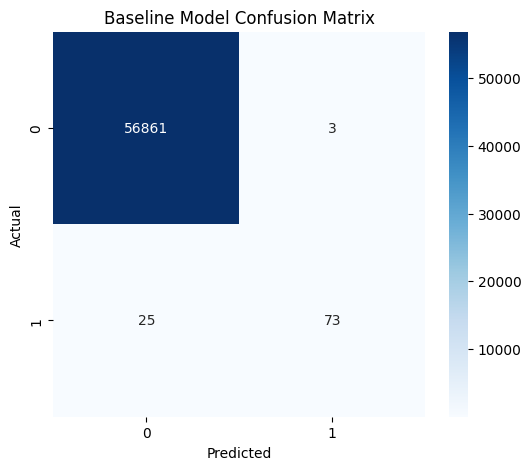

In [42]:
# Baseline confusion matrix
baseline_cm = confusion_matrix(
    y_test,
    baseline_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    baseline_cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Baseline Model Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

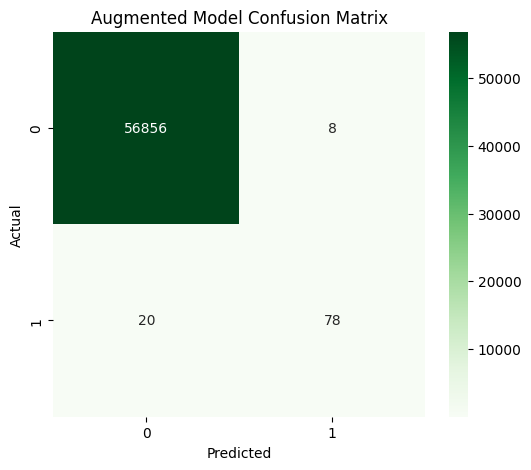

In [43]:
# Augmented confusion matrix
augmented_cm = confusion_matrix(
    y_test,
    augmented_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    augmented_cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Augmented Model Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

### Why confusion matrices?

Confusion matrices help visualize correct and incorrect fraud predictions.

### Insight

The augmented model reduced false negatives compared to the baseline model.

### Analysis

Reducing false negatives is extremely important in fraud detection because missed fraud cases can result in financial loss.

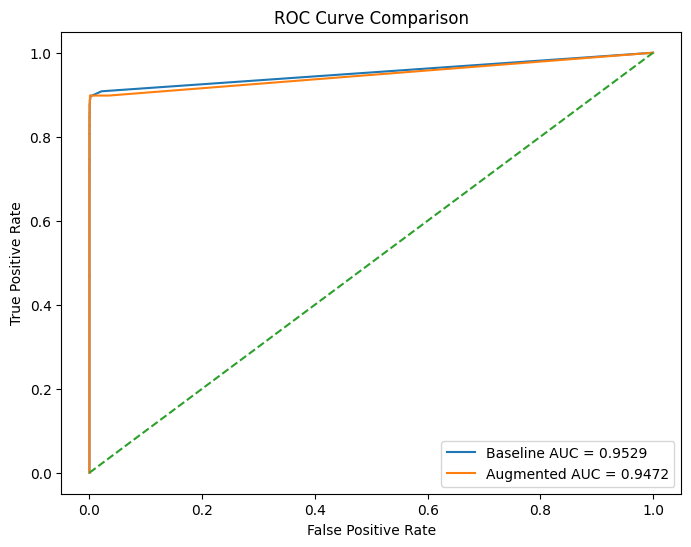

In [44]:
# ROC Curves
from sklearn.metrics import roc_curve

# Baseline probabilities
baseline_prob = baseline_model.predict_proba(
    X_test
)[:,1]

# Augmented probabilities
augmented_prob = augmented_model.predict_proba(
    X_test
)[:,1]

# ROC values
baseline_fpr, baseline_tpr, _ = roc_curve(
    y_test,
    baseline_prob
)

aug_fpr, aug_tpr, _ = roc_curve(
    y_test,
    augmented_prob
)

# AUC scores
baseline_auc = roc_auc_score(
    y_test,
    baseline_prob
)

augmented_auc = roc_auc_score(
    y_test,
    augmented_prob
)

# Plot
plt.figure(figsize=(8,6))

plt.plot(
    baseline_fpr,
    baseline_tpr,
    label=f'Baseline AUC = {baseline_auc:.4f}'
)

plt.plot(
    aug_fpr,
    aug_tpr,
    label=f'Augmented AUC = {augmented_auc:.4f}'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

### ROC Curve Analysis

ROC curves evaluate the tradeoff between true positive rate and false positive rate.

### Observation

Both models achieved strong AUC scores, indicating effective fraud detection capability.

### Analysis

The augmented model maintained strong classification performance after synthetic data augmentation.

In [45]:
# Print AUC scores
print(
    f"Baseline AUC: {baseline_auc:.4f}"
)

print(
    f"Augmented AUC: {augmented_auc:.4f}"
)

Baseline AUC: 0.9529
Augmented AUC: 0.9472


### AUC Score Interpretation

Both models achieved strong AUC scores above 0.94, indicating excellent fraud classification capability.

### Observation

Although the augmented model slightly reduced AUC score, it improved fraud recall performance, which is more important in fraud detection systems.

In [46]:
# Comparison table
comparison_table = pd.DataFrame({
    'Model': ['Baseline', 'Augmented'],
    'Accuracy': [
        baseline_accuracy,
        augmented_accuracy
    ],
    'AUC': [
        baseline_auc,
        augmented_auc
    ]
})

comparison_table

,Model,Accuracy,AUC
0,Baseline,0.999508,0.952908
1,Augmented,0.999508,0.947183


### Model Comparison Summary

The comparison table highlights the performance differences between the baseline and augmented fraud detection models.

### Key Findings

- Fraud recall improved after augmentation
- Overall accuracy remained stable
- The augmented model became better at identifying rare fraud transactions

### Conclusion

CTGAN-generated synthetic fraud data successfully improved fraud detection performance.

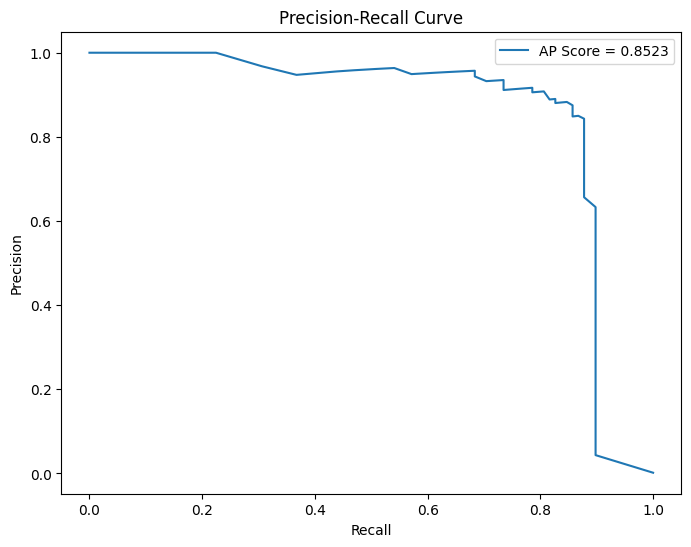

In [47]:
# Precision-Recall Curve
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score
)

# Precision-Recall values
precision, recall, thresholds = precision_recall_curve(
    y_test,
    augmented_prob
)

# Average Precision Score
avg_precision = average_precision_score(
    y_test,
    augmented_prob
)

# Plot
plt.figure(figsize=(8,6))

plt.plot(
    recall,
    precision,
    label=f'AP Score = {avg_precision:.4f}'
)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.legend()

plt.show()

### Why Precision-Recall Curve?

Precision-Recall curves are especially important for highly imbalanced datasets like fraud detection.

### Observation

The augmented model maintained strong precision while improving fraud recall performance.

### Analysis

The Precision-Recall curve confirms that the model performs effectively even when fraud cases are rare.

In [48]:
# Print Average Precision Score
print(
    f"Average Precision Score: {avg_precision:.4f}"
)

Average Precision Score: 0.8523


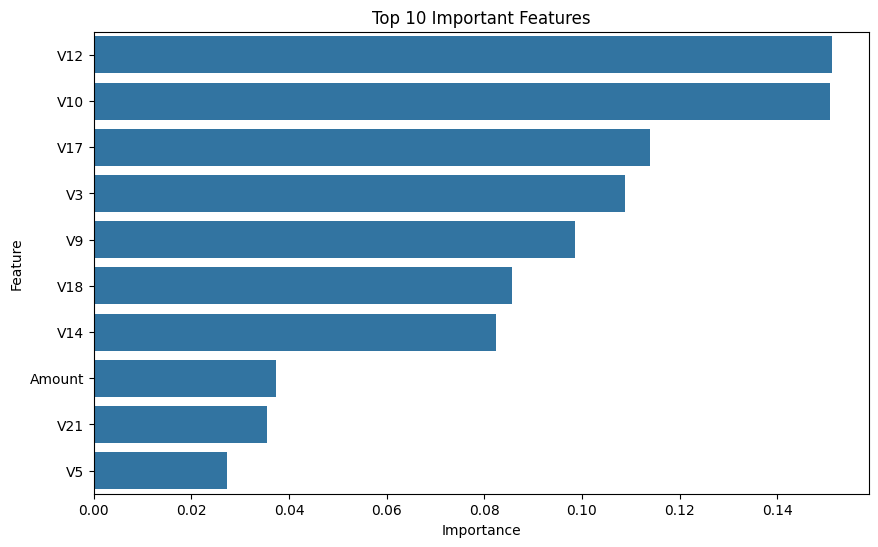

In [49]:
# Feature Importance
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': augmented_model.feature_importances_
})

# Sort
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# Top 10 features
top_features = feature_importance.head(10)

# Plot
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature'
)

plt.title("Top 10 Important Features")

plt.show()

### Feature Importance Analysis

The Random Forest model identified the most influential features contributing to fraud prediction.

### Insight

Certain PCA-transformed features contribute significantly more toward identifying fraudulent behavior.

### Analysis

Understanding feature importance improves interpretability and helps explain model decision-making.

# 1️⃣2️⃣ Model Saving and Deployment Preparation

In [50]:
# Save trained model
import joblib

joblib.dump(
    augmented_model,
    "fraud_detection_model.pkl"
)

print("Fraud Detection Model Saved")

Fraud Detection Model Saved


In [51]:
# Save scaler
joblib.dump(
    scaler,
    "scaler.pkl"
)

print("Scaler Saved")

Scaler Saved


In [52]:
# Download files
from google.colab import files

files.download("fraud_detection_model.pkl")

files.download("scaler.pkl")

files.download("synthetic_fraud.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 1️⃣3️⃣ Deployment Testing Dataset

In [53]:
# Create mixed transaction dataset
normal_sample = df[
    df['Class'] == 0
].drop('Class', axis=1).sample(
    15,
    random_state=42
)

fraud_sample = df[
    df['Class'] == 1
].drop('Class', axis=1).sample(
    5,
    random_state=42
)

mixed_transactions = pd.concat([
    normal_sample,
    fraud_sample
])

# Save file
mixed_transactions.to_csv(
    "mixed_transactions.csv",
    index=False
)

print("Mixed Transaction Dataset Created")

Mixed Transaction Dataset Created


### Why create a mixed transaction dataset?

The deployment dataset contains both normal and fraudulent transactions to simulate realistic fraud detection scenarios.

### Objective

To test the deployed Streamlit application using real transaction samples.

### Analysis

This mixed dataset helps demonstrate dynamic fraud detection capability during deployment testing.

In [54]:
# Download mixed test dataset
files.download(
    "mixed_transactions.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [132]:
# Reload ORIGINAL dataset again

original_df = pd.read_csv("creditcard.csv")

# Check columns
print(original_df.columns)

# Create mixed dataset
normal_sample = original_df[
    original_df['Class'] == 0
].sample(
    15,
    random_state=42
)

fraud_sample = original_df[
    original_df['Class'] == 1
].sample(
    5,
    random_state=42
)

# Combine
final_deployment = pd.concat([
    normal_sample,
    fraud_sample
])

# Remove ONLY target column
final_deployment = final_deployment.drop(
    columns=['Class']
)

# Verify Amount exists
print("\nFINAL COLUMNS:\n")

print(final_deployment.columns)

# Save CSV
final_deployment.to_csv(
    "FINAL_WORKING_TEST.csv",
    index=False
)

print("\nFINAL working deployment CSV created")

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

FINAL COLUMNS:

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount'],
      dtype='object')

FINAL working deployment CSV created


In [133]:
!pip install streamlit -q

In [140]:
!pip install pyngrok -q

# 1️⃣4️⃣ Streamlit Deployment

## AI Fraud Detection Dashboard

In [135]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib
import matplotlib.pyplot as plt

# --------------------------------
# PAGE CONFIG
# --------------------------------
st.set_page_config(
    page_title="AI Fraud Detection Dashboard",
    page_icon="💳",
    layout="wide"
)

# --------------------------------
# CUSTOM CSS
# --------------------------------
st.markdown("""
<style>

.main {
    background-color: #0E1117;
}

h1, h2, h3, h4 {
    color: white;
}

.stMetric {
    background-color: #1E1E1E;
    padding: 15px;
    border-radius: 12px;
    text-align: center;
    border: 1px solid #333;
}

.block-container {
    padding-top: 2rem;
}

[data-testid="stSidebar"] {
    background-color: #1A1C24;
}

</style>
""", unsafe_allow_html=True)

# --------------------------------
# LOAD MODEL
# --------------------------------
model = joblib.load(
    "fraud_detection_model.pkl"
)

# --------------------------------
# SIDEBAR
# --------------------------------
st.sidebar.title("🧠 Project Information")

st.sidebar.markdown("""
## AI-Powered Fraud Detection

This dashboard uses:

- 🤖 Random Forest Classifier
- 🧬 CTGAN Synthetic Data
- 📊 Fraud Probability Analysis
- 📈 Machine Learning Dashboard

---

### Features

✅ Fraud Detection
✅ Synthetic Data Augmentation
✅ Risk Analysis
✅ Downloadable Reports
✅ Interactive Dashboard

---
""")

# --------------------------------
# MAIN TITLE
# --------------------------------
st.title("💳 AI Fraud Detection Dashboard")

st.markdown("""
Analyze uploaded financial transaction datasets and identify potentially fraudulent activities using Machine Learning and CTGAN-generated synthetic fraud data.
""")

# --------------------------------
# FILE UPLOADER
# --------------------------------
uploaded_file = st.file_uploader(
    "📂 Upload Transaction CSV File",
    type=["csv"]
)

# --------------------------------
# PROCESS FILE
# --------------------------------
if uploaded_file is not None:

    # Read CSV
    data = pd.read_csv(uploaded_file)

    # --------------------------------
    # REMOVE CLASS COLUMN IF EXISTS
    # --------------------------------
    if 'Class' in data.columns:
        data = data.drop('Class', axis=1)

    # --------------------------------
    # DATASET PREVIEW
    # --------------------------------
    st.subheader("📋 Uploaded Dataset Preview")

    st.dataframe(
        data.head(),
        use_container_width=True
    )

    st.info(
        f"Dataset contains {data.shape[0]} transactions and {data.shape[1]} features."
    )

    # --------------------------------
    # RUN MODEL
    # --------------------------------
    if st.button("🚀 Run Fraud Detection"):

        try:

            # --------------------------------
            # INPUT ARRAY
            # --------------------------------
            input_array = data.values

            # --------------------------------
            # PREDICTIONS
            # --------------------------------
            predictions = model.predict(input_array)

            probabilities = model.predict_proba(
                input_array
            )[:,1]

            # --------------------------------
            # RESULTS
            # --------------------------------
            results = pd.DataFrame({

                'Transaction_ID': range(
                    1,
                    len(predictions)+1
                ),

                'Fraud_Probability (%)': (
                    probabilities * 100
                ).round(2)

            })

            results['Prediction'] = predictions

            results['Prediction'] = results[
                'Prediction'
            ].map({
                0: 'Normal',
                1: 'Fraud'
            })

            # --------------------------------
            # RISK LEVEL
            # --------------------------------
            def risk_level(prob):

                if prob < 30:
                    return "🟢 Low"

                elif prob < 70:
                    return "🟠 Medium"

                else:
                    return "🔴 High"

            results['Risk_Level'] = results[
                'Fraud_Probability (%)'
            ].apply(risk_level)

            # --------------------------------
            # METRICS
            # --------------------------------
            fraud_count = (
                results['Prediction'] == 'Fraud'
            ).sum()

            normal_count = (
                results['Prediction'] == 'Normal'
            ).sum()

            total_transactions = len(results)

            fraud_percentage = (
                fraud_count / total_transactions
            ) * 100

            avg_probability = results[
                'Fraud_Probability (%)'
            ].mean()

            # --------------------------------
            # SUMMARY METRICS
            # --------------------------------
            st.subheader("📊 Fraud Detection Summary")

            col1, col2, col3, col4 = st.columns(4)

            col1.metric(
                "Total Transactions",
                total_transactions
            )

            col2.metric(
                "Fraud Detected",
                fraud_count
            )

            col3.metric(
                "Fraud Percentage",
                f"{fraud_percentage:.2f}%"
            )

            col4.metric(
                "Average Fraud Risk",
                f"{avg_probability:.2f}%"
            )

            # --------------------------------
            # ALERT
            # --------------------------------
            if fraud_count > 0:

                st.error(
                    f"🚨 ALERT: {fraud_count} potentially fraudulent transactions detected!"
                )

            else:

                st.success(
                    "✅ No fraudulent transactions detected."
                )

            # --------------------------------
            # SIDE BY SIDE CHARTS
            # --------------------------------
            st.subheader("📈 Fraud Analytics Dashboard")

            chart1, chart2 = st.columns(2)

            # --------------------------------
            # PIE CHART
            # --------------------------------
            with chart1:

                fig1, ax1 = plt.subplots(
                    figsize=(6,6)
                )

                ax1.pie(
                    [normal_count, fraud_count],
                    labels=['Normal', 'Fraud'],
                    autopct='%1.1f%%',
                    colors=['#36A2EB', '#FF4B4B'],
                    textprops={'fontsize': 12}
                )

                ax1.set_title(
                    "Fraud vs Normal Transactions",
                    fontsize=14
                )

                st.pyplot(fig1)

                plt.close(fig1)

            # --------------------------------
            # HISTOGRAM
            # --------------------------------
            with chart2:

                fig2, ax2 = plt.subplots(
                    figsize=(7,6)
                )

                ax2.hist(
                    results['Fraud_Probability (%)'],
                    bins=10,
                    color='#36A2EB',
                    edgecolor='white'
                )

                ax2.set_title(
                    "Fraud Risk Score Distribution",
                    fontsize=14
                )

                ax2.set_xlabel(
                    "Fraud Probability (%)"
                )

                ax2.set_ylabel(
                    "Transaction Count"
                )

                st.pyplot(fig2)

                plt.close(fig2)

            # --------------------------------
            # SUSPICIOUS TRANSACTIONS
            # --------------------------------
            st.subheader("🚨 Suspicious Transactions")

            suspicious = results[
                results['Prediction'] == 'Fraud'
            ]

            if len(suspicious) > 0:

                st.dataframe(
                    suspicious,
                    use_container_width=True
                )

            else:

                st.info(
                    "No suspicious transactions found."
                )

            # --------------------------------
            # FULL RESULTS
            # --------------------------------
            st.subheader("📝 Full Prediction Results")

            st.dataframe(
                results,
                use_container_width=True
            )

            # --------------------------------
            # DOWNLOAD BUTTON
            # --------------------------------
            csv = results.to_csv(index=False)

            st.download_button(
                label="⬇️ Download Results CSV",
                data=csv,
                file_name='fraud_detection_results.csv',
                mime='text/csv'
            )

        except Exception as e:

            st.error(
                f"❌ Error Processing File: {e}"
            )

Overwriting app.py


In [136]:
from pyngrok import ngrok

ngrok.set_auth_token("YOUR_NGROK_TOKEN")

In [137]:
!pkill streamlit

In [138]:
!streamlit run app.py &>/content/logs.txt &

In [139]:
from pyngrok import ngrok

public_url = ngrok.connect(
    8501,
    domain=None
)

print(public_url)

NgrokTunnel: "https://transport-drone-spellbind.ngrok-free.dev" -> "http://localhost:8501"


# ✅ Final Conclusion

This project successfully demonstrates how Generative AI can improve fraud detection performance in highly imbalanced financial datasets.

## Key Achievements

- Performed Exploratory Data Analysis (EDA)
- Identified severe class imbalance
- Generated synthetic fraud data using CTGAN
- Improved fraud recall using synthetic augmentation
- Built a Random Forest fraud detection model
- Developed an interactive Streamlit dashboard for deployment

## Final Outcome

The final AI-powered fraud detection system can analyze uploaded transaction datasets and identify potentially fraudulent activities through an interactive dashboard interface.

## Technologies Used

- Python
- Scikit-learn
- CTGAN
- Streamlit
- Pandas
- Matplotlib
- Seaborn

## Future Improvements

- Deploy on Streamlit Cloud
- Add real-time API prediction support
- Experiment with XGBoost and Deep Learning models
- Improve synthetic data quality further